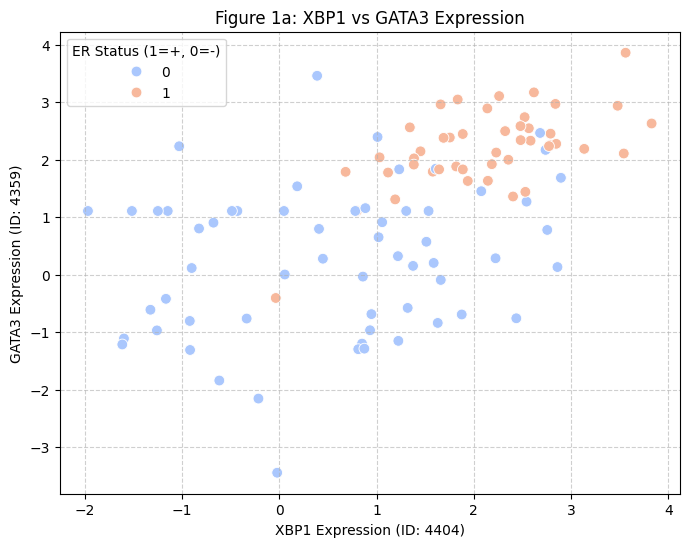

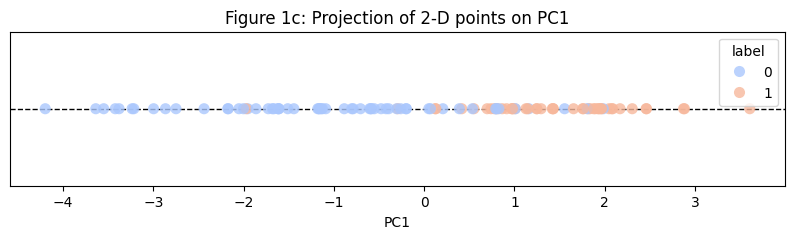

Variance explained by PC1: 77.92%


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# --- Data Loading (Your Modified Structure) ---
labels = pd.read_csv('class.tsv', sep='\t', header=None, names=['label'])
# Skipping the 18 lines of metadata to avoid ParserErrors
mapping = pd.read_csv('columns.tsv.gz', sep='\t', skiprows=18)
data = pd.read_csv('filtered.tsv.gz', sep='\t')

# Column picking and cleaning
data.columns = data.columns.astype(str).str.strip()
mapping['GeneSymbol'] = mapping['GeneSymbol'].astype(str).str.strip()
mapping['ID'] = mapping['ID'].astype(str).str.strip()

# Target IDs
xbp1_id = '4404' # Specified in the README
gata_row = mapping[mapping['GeneSymbol'] == 'GATA3']
if gata_row.empty:
    gata_row = mapping[mapping['GeneSymbol'].str.contains('GATA3', na=False)]
gata3_id = gata_row['ID'].values[0]

# Creating dataframe for analysis
df = pd.DataFrame({
    'XBP1': data[xbp1_id],
    'GATA3': data[gata3_id],
    'label': labels['label']
})

# --- Task 1: Scatter Plot (Figure 1a) ---
plt.figure(figsize=(8, 6))
# Using seaborn for easier coloring by label
sns.scatterplot(data=df, x='XBP1', y='GATA3', hue='label', palette='coolwarm', s=60)
plt.title('Figure 1a: XBP1 vs GATA3 Expression')
plt.xlabel('XBP1 Expression (ID: 4404)')
plt.ylabel(f'GATA3 Expression (ID: {gata3_id})')
plt.legend(title='ER Status (1=+, 0=-)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- Task 2: PCA and PC1 Projection (Figure 1c) ---
# 1. Run PCA on the 2D matrix (XBP1 and GATA3)
pca_input = df[['XBP1', 'GATA3']]
pca = PCA(n_components=1)
df['PC1'] = pca.fit_transform(pca_input)

# 2. Generate Figure 1c (Projecting 2D points on PC1)
plt.figure(figsize=(10, 2))
# We use a stripplot to show the points along a single horizontal axis
sns.stripplot(data=df, x='PC1', hue='label', palette='coolwarm', size=8, alpha=0.8, jitter=False)
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.title('Figure 1c: Projection of 2-D points on PC1')
plt.yticks([]) # Hide Y-axis as it is 1D
plt.show()

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")